In [69]:
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_regression

In [22]:
PATH = 'datasets/gold_data.csv'
df = pd.read_csv(PATH)
df['Date'] = pd.to_datetime(df['Date'])
df.head()
len(df)

1279

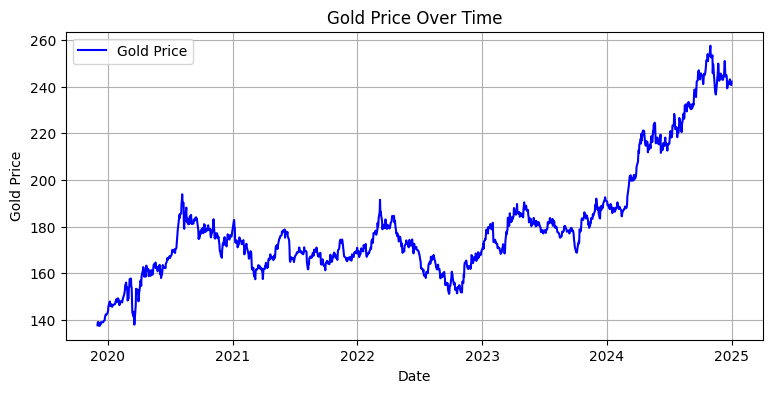

In [23]:
plt.figure(figsize=(9,4))
plt.plot(df['Date'], df['Gold_Price'], label='Gold Price', color='blue')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.title('Gold Price Over Time')
plt.grid(True)
plt.legend()
plt.show()

**Correlation analysis**

In [29]:
target = 'Gold_Price' 
X = df.drop(columns=[target, 'Date'])  
y = df[target]

In [30]:
corr_target = X.corrwith(y).sort_values(ascending=False)
print("Correlation with target:\n", corr_target)

Correlation with target:
 ^GSPC            0.825149
SLV              0.792803
Inflation        0.661445
USD_JPY          0.614913
Interest_Rate    0.570467
Crude_Oil        0.153673
USD_EUR         -0.124166
dtype: float64


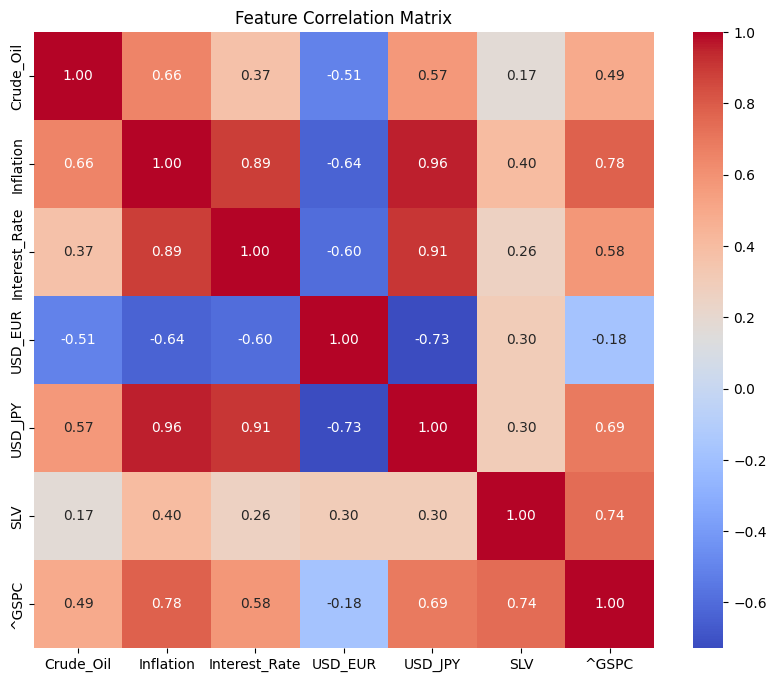

In [31]:
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [33]:
high_corr = X.corr().abs()
upper = high_corr.where(~np.tril(np.ones(high_corr.shape), k=0).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
X_reduced = X.drop(columns=to_drop)
print("Dropped highly correlated features:", to_drop)

Dropped highly correlated features: ['USD_JPY']


In [35]:
mi = mutual_info_regression(X_reduced, y)
mi_scores = pd.Series(mi, index=X_reduced.columns).sort_values(ascending=False)
print("Mutual Information Scores:\n", mi_scores)

Mutual Information Scores:
 Inflation        1.739963
Crude_Oil        1.510628
^GSPC            1.263894
SLV              1.191362
Interest_Rate    1.125595
USD_EUR          0.970811
dtype: float64


In [37]:
drop = ['USD_JPY']
df = df.drop(columns=drop)

**LineCharts**

In [42]:
scaler = MinMaxScaler()
scale_features = [col for col in df.columns if col not in ['Date']]

df[scale_features] = scaler.fit_transform(df[scale_features])

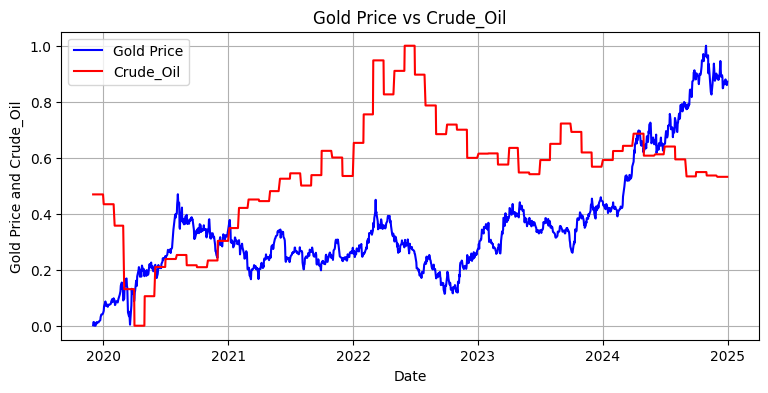

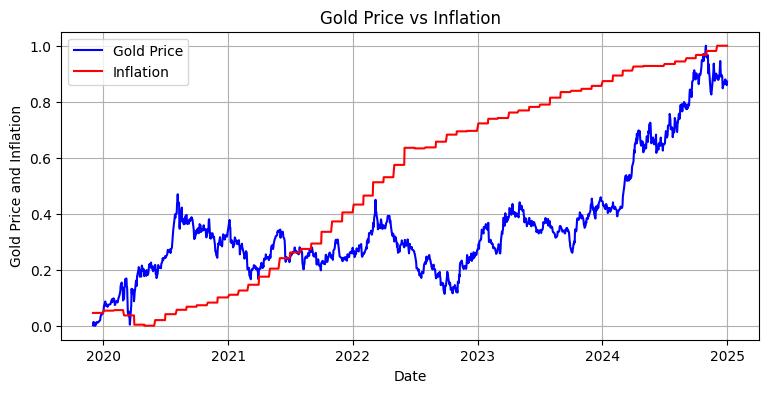

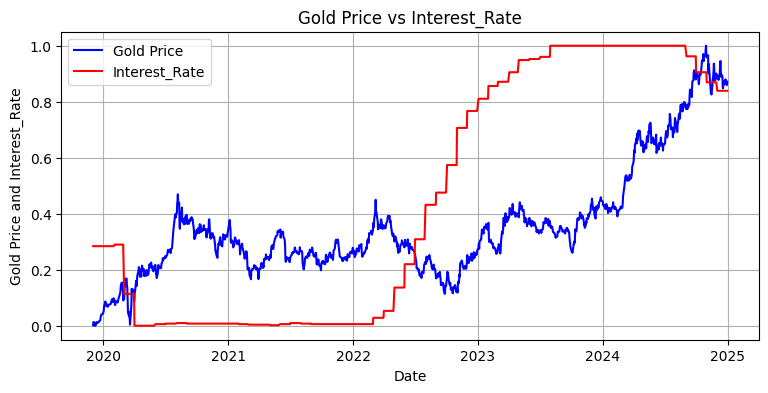

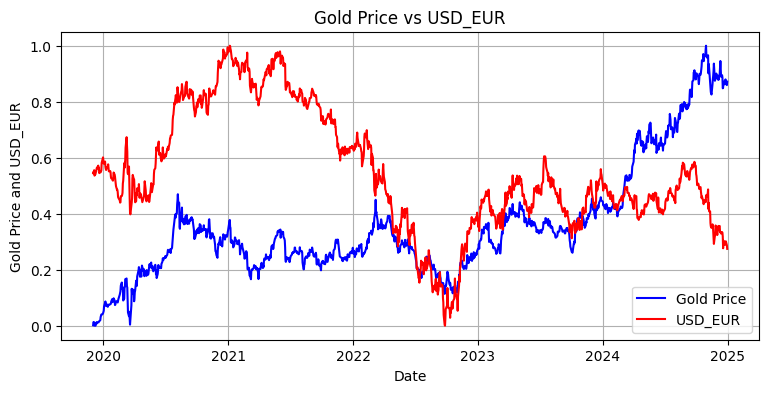

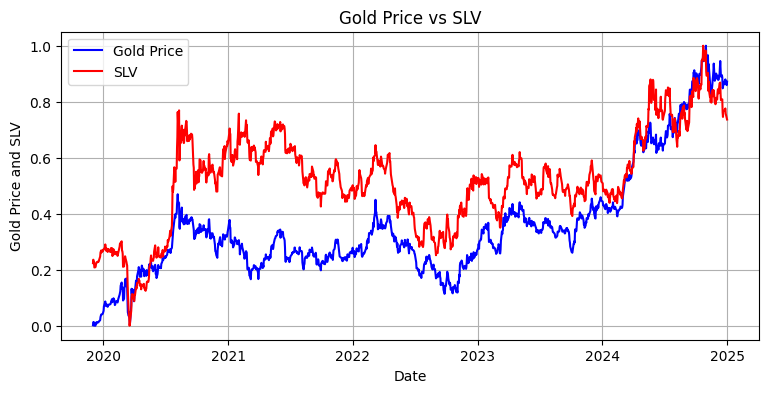

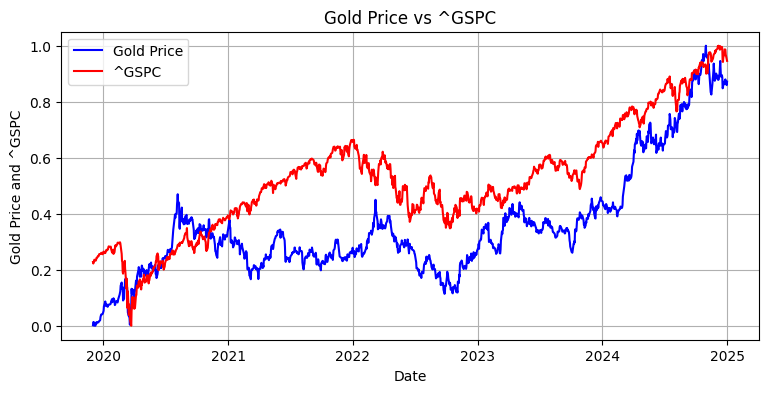

In [43]:
features = [col for col in df.columns if col not in ['Date', 'Gold_Price']]

for feat in features:
    plt.figure(figsize=(9,4))
    plt.plot(df['Date'], df['Gold_Price'], label='Gold Price', color='blue')
    plt.plot(df['Date'], df[feat], label=f'{feat}', color='red')
    plt.xlabel('Date')
    plt.ylabel(f'Gold Price and {feat}')
    plt.title(f'Gold Price vs {feat}')
    plt.grid(True)
    plt.legend()
    plt.show()
    print("\n\n")

**Effect of sentiments**

In [57]:
def read_sentiment_df(df: pd.DataFrame) -> pd.DataFrame:
    start_date = df['Date'][0]
    path = '../gdelt_gold_news_sentiments.csv'
    sentiment_df = pd.read_csv(path, parse_dates=['date'])

    start_date = pd.to_datetime(start_date)
    sentiment_df = sentiment_df.query("date >= @start_date")

    return sentiment_df

In [58]:
sentiment_df = read_sentiment_df(df)

In [63]:
sentiment_df = sentiment_df.rename(columns={'date': 'Date'})

In [65]:
merged = pd.merge(df, sentiment_df, on='Date', how='inner')
merged.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,SLV,^GSPC,text,sentiment
0,2019-12-02,0.001751,0.468993,0.04576,0.284091,0.544606,0.223575,0.227485,"Gold prices are experiencing some volatility, ...",negative
1,2019-12-03,0.012758,0.468993,0.04576,0.284091,0.549832,0.235753,0.222120,"Gold prices are experiencing some volatility, ...",negative
2,2019-12-04,0.011174,0.468993,0.04576,0.284091,0.544979,0.221627,0.227197,Gold prices are influenced by US-China trade u...,negative
3,2019-12-05,0.011841,0.468993,0.04576,0.284091,0.555431,0.226011,0.228409,Gold prices are influenced by US-China trade u...,negative
4,2019-12-06,0.000333,0.468993,0.04576,0.284091,0.536021,0.207988,0.235801,Wildsky Resources Inc. announced a purchase an...,positive


<Axes: >

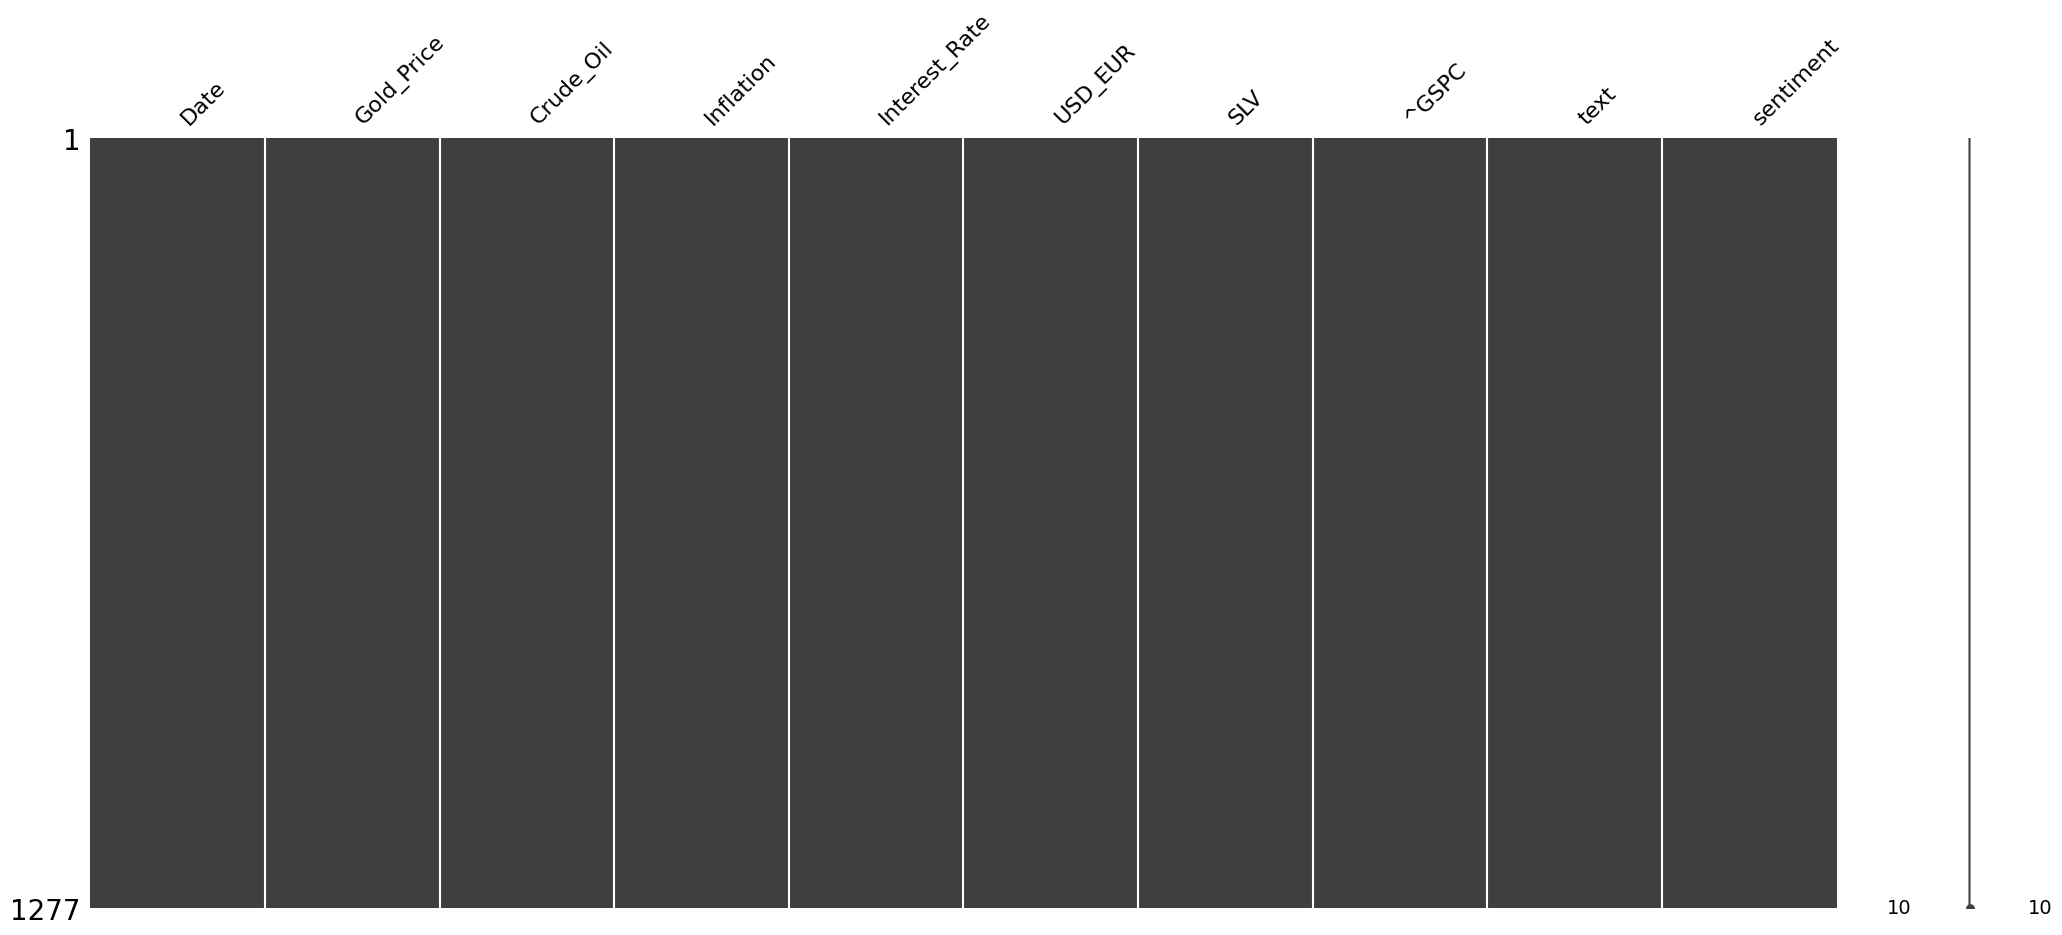

In [68]:
df = merged.copy()
len(df)
msno.matrix(df)

In [82]:
merged.isnull().sum()

Date             0
Gold_Price       0
Crude_Oil        0
Inflation        0
Interest_Rate    0
USD_EUR          0
SLV              0
^GSPC            0
text             0
sentiment        0
dtype: int64

In [70]:
le = LabelEncoder()
df['sent_enc'] = le.fit_transform(df['sentiment'])
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,SLV,^GSPC,text,sentiment,sent_enc
0,2019-12-02,0.001751,0.468993,0.04576,0.284091,0.544606,0.223575,0.227485,"Gold prices are experiencing some volatility, ...",negative,0
1,2019-12-03,0.012758,0.468993,0.04576,0.284091,0.549832,0.235753,0.222120,"Gold prices are experiencing some volatility, ...",negative,0
2,2019-12-04,0.011174,0.468993,0.04576,0.284091,0.544979,0.221627,0.227197,Gold prices are influenced by US-China trade u...,negative,0
3,2019-12-05,0.011841,0.468993,0.04576,0.284091,0.555431,0.226011,0.228409,Gold prices are influenced by US-China trade u...,negative,0
4,2019-12-06,0.000333,0.468993,0.04576,0.284091,0.536021,0.207988,0.235801,Wildsky Resources Inc. announced a purchase an...,positive,2


In [71]:
drop = ['text', 'sentiment']
df = df.drop(columns=drop)
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,SLV,^GSPC,sent_enc
0,2019-12-02,0.001751,0.468993,0.04576,0.284091,0.544606,0.223575,0.227485,0
1,2019-12-03,0.012758,0.468993,0.04576,0.284091,0.549832,0.235753,0.222120,0
2,2019-12-04,0.011174,0.468993,0.04576,0.284091,0.544979,0.221627,0.227197,0
3,2019-12-05,0.011841,0.468993,0.04576,0.284091,0.555431,0.226011,0.228409,0
4,2019-12-06,0.000333,0.468993,0.04576,0.284091,0.536021,0.207988,0.235801,2


In [75]:
df['sent_enc'].value_counts()

sent_enc
2    679
0    320
1    278
Name: count, dtype: int64

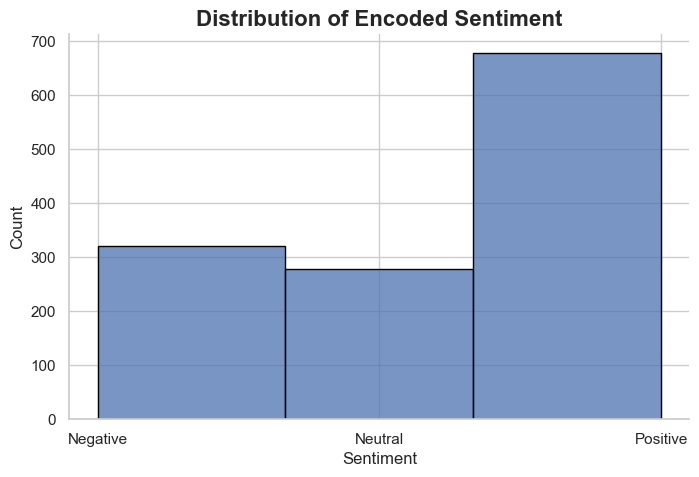

In [76]:
sns.set(style="whitegrid")  
plt.figure(figsize=(8,5))


sns.histplot(
    data=df, 
    x='sent_enc', 
    bins=3,            
    kde=False,         
    color='#4c72b0',  
    edgecolor='black' 
)

plt.title('Distribution of Encoded Sentiment', fontsize=16, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1, 2], ['Negative', 'Neutral', 'Positive'])  

sns.despine()

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_14580\2410352287.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'])


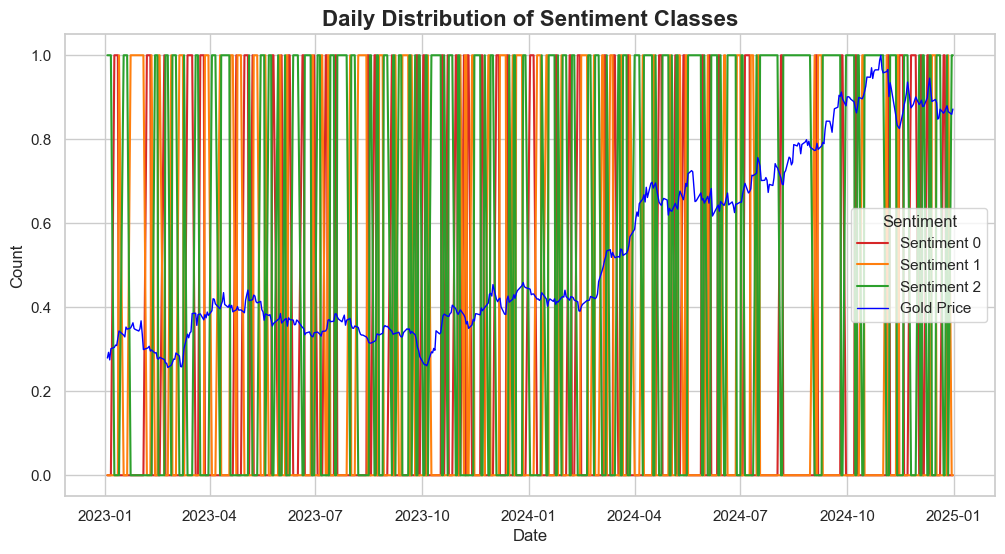

In [84]:
start_date = "2023-01-01"
df = df.query("Date >= @start_date")
df['Date'] = pd.to_datetime(df['Date'])


sent_counts = df.groupby(['Date', 'sent_enc']).size().reset_index(name='count')
sent_counts_pivot = sent_counts.pivot(index='Date', columns='sent_enc', values='count').fillna(0)

plt.figure(figsize=(12,6))
sns.set(style="whitegrid")

for col, color in zip(sent_counts_pivot.columns, ['#d62728','#ff7f0e','#2ca02c']): 
    plt.plot(sent_counts_pivot.index, sent_counts_pivot[col], label=f'Sentiment {col}', color=color)
plt.plot(df['Date'], df['Gold_Price'], label='Gold Price', color='blue', linewidth=1)
plt.title('Daily Distribution of Sentiment Classes', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Sentiment')
plt.show()

In [85]:
#--- the distribution of classes does not really match the trend of the price. using this in modeling will not pretty much increase the performance. in my opinion

**Testing increasing decreasing indicator**

In [87]:
df['increase_ind'] = df['Gold_Price'].diff().apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))


C:\Users\User\AppData\Local\Temp\ipykernel_14580\3754143843.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['increase_ind'] = df['Gold_Price'].diff().apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))


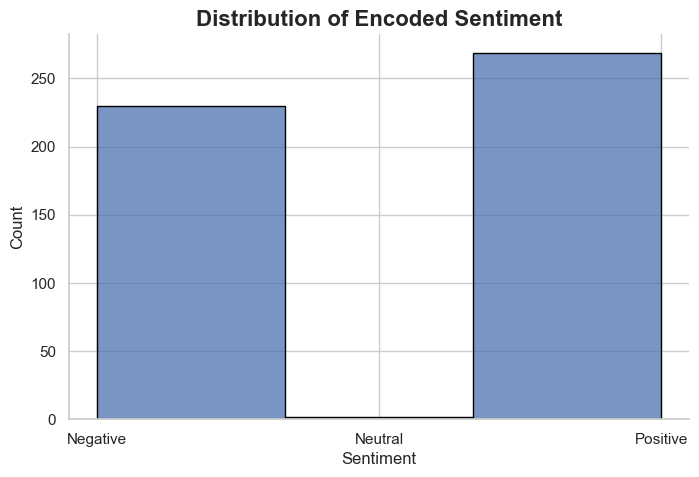

In [89]:
sns.set(style="whitegrid")  
plt.figure(figsize=(8,5))


sns.histplot(
    data=df, 
    x='increase_ind', 
    bins=3,            
    kde=False,         
    color='#4c72b0',  
    edgecolor='black' 
)

plt.title('Distribution of Encoded Sentiment', fontsize=16, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([-1, 0, 1], ['Negative', 'Neutral', 'Positive'])  

sns.despine()

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_14580\3887729978.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'])


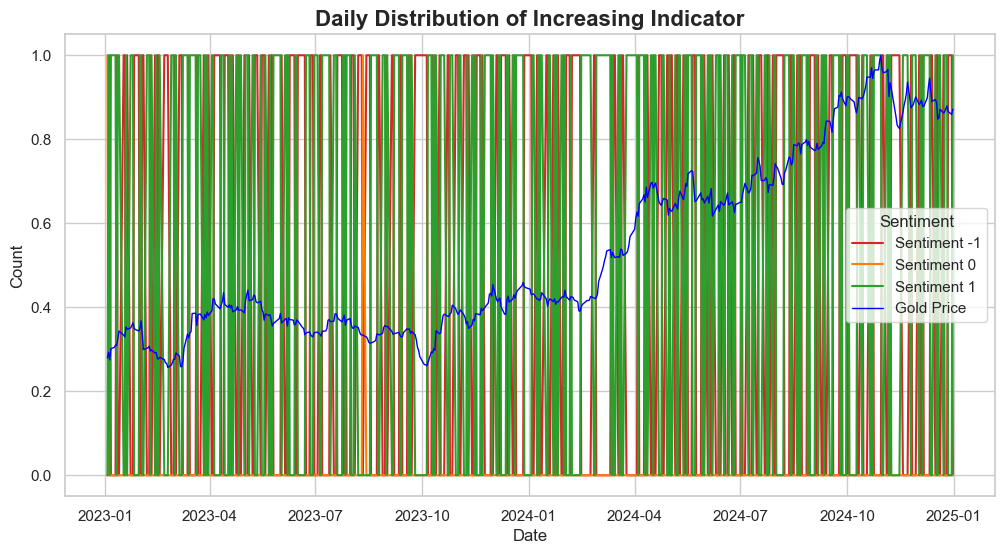

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])


sent_counts = df.groupby(['Date', 'increase_ind']).size().reset_index(name='count')
sent_counts_pivot = sent_counts.pivot(index='Date', columns='increase_ind', values='count').fillna(0)

plt.figure(figsize=(12,6))
sns.set(style="whitegrid")

for col, color in zip(sent_counts_pivot.columns, ['#d62728','#ff7f0e','#2ca02c']): 
    plt.plot(sent_counts_pivot.index, sent_counts_pivot[col], label=f'Sentiment {col}', color=color)
plt.plot(df['Date'], df['Gold_Price'], label='Gold Price', color='blue', linewidth=1)
plt.title('Daily Distribution of Increasing Indicator', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Sentiment')
plt.show()

In [93]:
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,SLV,^GSPC,sent_enc,increase_ind
776,2023-01-03,0.279186,0.614588,0.722545,0.810606,0.351997,0.528008,0.411833,2,0
777,2023-01-04,0.292612,0.614588,0.722545,0.810606,0.374767,0.520214,0.419316,2,1
778,2023-01-05,0.274683,0.614588,0.722545,0.810606,0.338186,0.495860,0.407670,2,-1
779,2023-01-06,0.301284,0.614588,0.722545,0.810606,0.374393,0.521676,0.430246,2,1
780,2023-01-09,0.304536,0.614588,0.722545,0.810606,0.426652,0.512908,0.429469,0,1


In [95]:
path = 'datasets/mega_dataset.csv'
df.to_csv(path, index=False)